In [3]:
import os
import sys
sys.path.append("..")

from src.data_loader import load_data
from src.eda import *
from src.visualization import *

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [4]:
df = load_data("../data/raw/dataset.csv") # Carrega o dataset

In [ ]:
df.head() # Primeiras cinco linhas do dataset

In [ ]:
df.tail() # últimas cinco linhas do dataset

In [5]:
df.shape # Quantidade de linhas e colunas do dataset

(6000, 35)

In [ ]:
df.info() # Tipos de dados das colunas do dataset

In [5]:
tabela_estatistica = df.describe()

tabela_estatistica = tabela_estatistica.drop(columns=["person_id"])

tabela_estatistica = tabela_estatistica.rename(index={
    "count": "Quantidade",
    "mean": "Média",
    "std": "Desvio padrão",
    "min": "Mínimo",
    "25%": "Q1",
    "50%": "Mediana",
    "75%": "Q3",
    "max": "Máximo"
})

tabela_estatistica.round(2)

,mood_score,stress_level,fear_tolerance,risk_tolerance,humor_preference,openness_score,romance_interest,social_media_hours_per_day,streaming_subscription_count
Quantidade,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
Média,6.20,5.01,5.03,5.03,5.98,5.56,5.06,2.59,2.35
Desvio padrão,1.93,2.10,2.35,2.18,2.11,2.13,2.23,1.84,1.31
Mínimo,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00
Q1,4.90,3.60,3.30,3.50,4.50,4.10,3.40,1.20,1.00
Mediana,6.20,5.00,5.00,5.00,6.00,5.60,5.00,2.20,2.00
Q3,7.50,6.50,6.70,6.60,7.50,7.10,6.60,3.50,3.00
Máximo,10.00,10.00,10.00,10.00,10.00,10.00,10.00,12.00,5.00


Frequência das variáveis categóricas

A tabela abaixo apresenta as frequências das categorias das variáveis categóricas.

As variáveis categóricas analisadas são:

`gender`, `personality_type`, `hobbies`, `favorite_game_genre`, `favorite_music_genre`, `preferred_language`, `relationship_status`, `favorite_season`, `sleep_pattern`, `occupation`, `preferred_streaming_platform`, `preferred_watch_time`, `viewing_companion`, `snack_preference`, `preferred_device`, `preferred_movie_length`, `favorite_movie_era`, `pet_ownership`, `travel_frequency`, `book_reading_frequency` e `recommended_movie_genre`.

Para visualizar uma variável específica, substitua `"personality_type"` pelo nome da variável desejada no código abaixo.

In [ ]:
frequencias = get_categorical_frequencies(df) # Frequências das variáveis categóricas
frequencias[frequencias["variable"] == "personality_type"]

In [5]:
df.nunique() # cardinalidade por coluna

person_id                       6000
age_group                          5
gender                             3
personality_type                   3
mood_score                        91
stress_level                      91
hobbies                         1529
favorite_game_genre                8
favorite_music_genre               8
fear_tolerance                    91
risk_tolerance                    91
humor_preference                  91
openness_score                    91
romance_interest                  91
social_media_hours_per_day       109
preferred_language                 6
relationship_status                4
favorite_season                    4
sleep_pattern                      3
education_level                    5
occupation                        11
income_bracket                     5
preferred_streaming_platform       7
preferred_watch_time               4
viewing_companion                  5
snack_preference                   6
preferred_device                   5
p

In [4]:
get_missing_values(df) # Quantidade e percentual de valores ausentes por coluna com valores ausentes

,qtd_ausentes,pct_ausentes
favorite_game_genre,360,6.00
favorite_music_genre,356,5.93


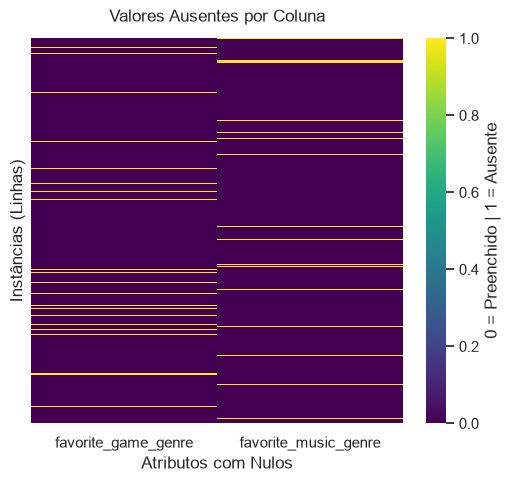

In [6]:
plot_missing_values_heatmap(df) # Gráfico de calor das variáveis com valores ausentes

In [ ]:
duplicados = df.duplicated().sum()
print(f"Número de linhas totalmente duplicadas: {duplicados}")

duplicados_sem_id = df.drop(columns=["person_id"]).duplicated().sum()
print(f"Número de linhas duplicadas (ignorando o Id): {duplicados_sem_id}")

In [10]:
def verificar_valores_invalidos(df):
    resultados = []

    variaveis_escala = [
        "mood_score",
        "stress_level",
        "fear_tolerance",
        "risk_tolerance",
        "humor_preference",
        "openness_score",
        "romance_interest"
    ]

    for coluna in variaveis_escala:
        invalidos = ((df[coluna] < 1) | (df[coluna] > 10)).sum()

        resultados.append({
            "variavel": coluna,
            "minimo": df[coluna].min(),
            "maximo": df[coluna].max(),
            "valores_invalidos": invalidos
        })

    coluna = "social_media_hours_per_day"
    resultados.append({
        "variavel": coluna,
        "minimo": df[coluna].min(),
        "maximo": df[coluna].max(),
        "valores_invalidos": (df[coluna] < 0).sum()
    })

    coluna = "streaming_subscription_count"
    resultados.append({
        "variavel": coluna,
        "minimo": df[coluna].min(),
        "maximo": df[coluna].max(),
        "valores_invalidos": (df[coluna] < 0).sum()
    })

    return pd.DataFrame(resultados)

In [11]:
verificar_valores_invalidos(df)

,variavel,minimo,maximo,valores_invalidos
0,mood_score,1.0,10.0,0
1,stress_level,1.0,10.0,0
2,fear_tolerance,1.0,10.0,0
3,risk_tolerance,1.0,10.0,0
4,humor_preference,1.0,10.0,0
5,openness_score,1.0,10.0,0
6,romance_interest,1.0,10.0,0
7,social_media_hours_per_day,0.0,12.0,0
8,streaming_subscription_count,0.0,5.0,0


In [12]:
variaveis_numericas_esperadas = [
    "person_id",
    "mood_score",
    "stress_level",
    "fear_tolerance",
    "risk_tolerance",
    "humor_preference",
    "openness_score",
    "romance_interest",
    "social_media_hours_per_day",
    "streaming_subscription_count"
]

for coluna in variaveis_numericas_esperadas:
    print(f"{coluna}: {df[coluna].dtype}")

person_id: int64
mood_score: float64
stress_level: float64
fear_tolerance: float64
risk_tolerance: float64
humor_preference: float64
openness_score: float64
romance_interest: float64
social_media_hours_per_day: float64
streaming_subscription_count: int64


In [6]:
df_limpo = load_data("../data/processed/dataset_clean.csv") # Carrega o dataset 

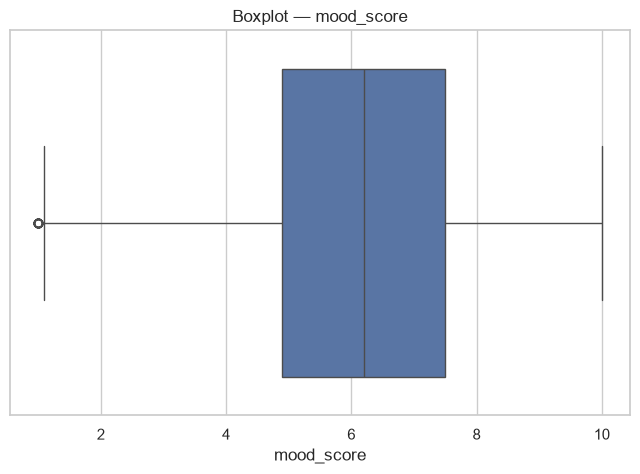

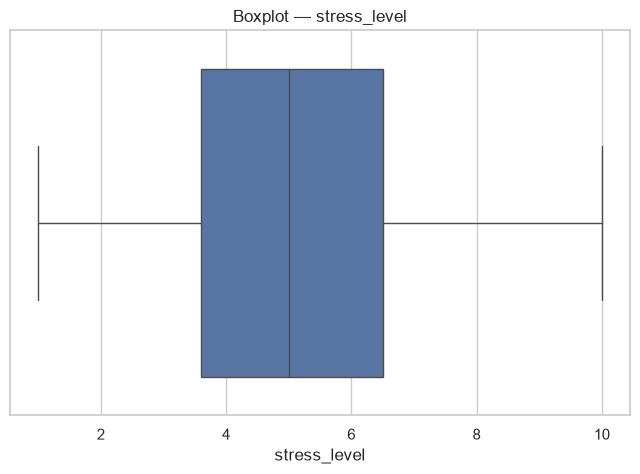

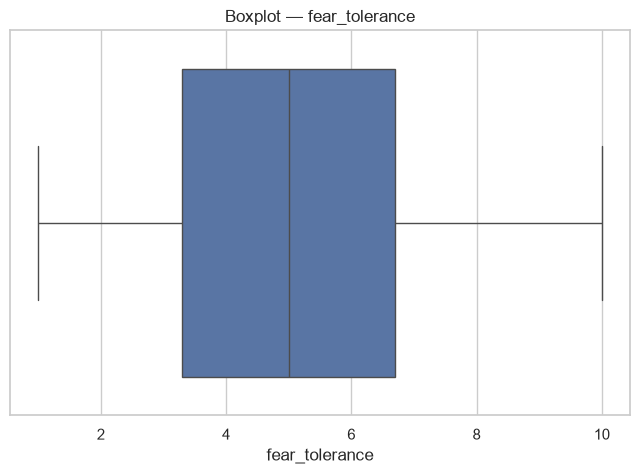

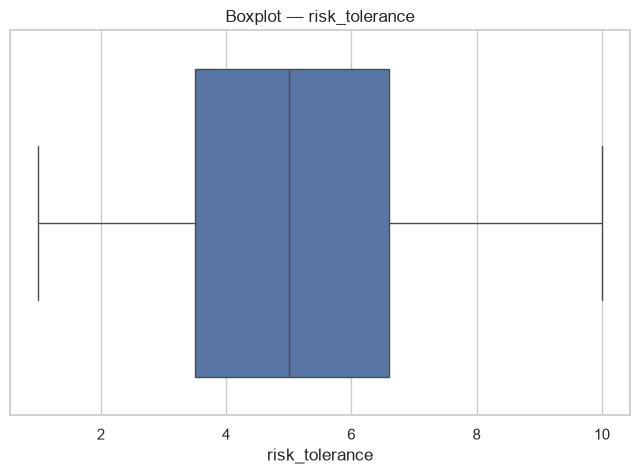

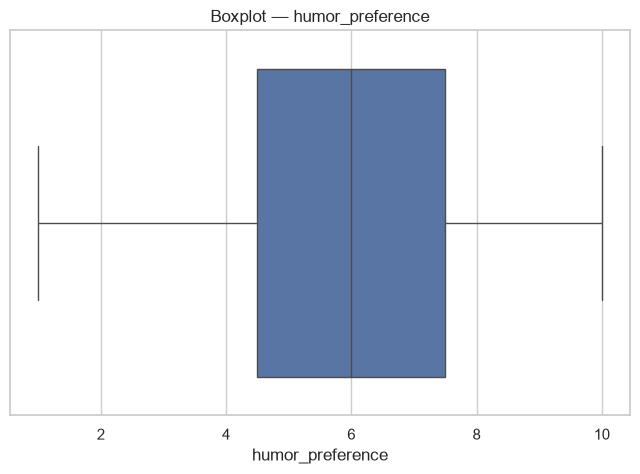

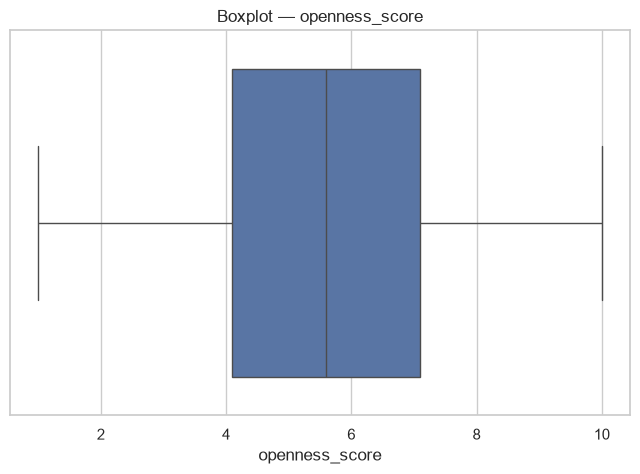

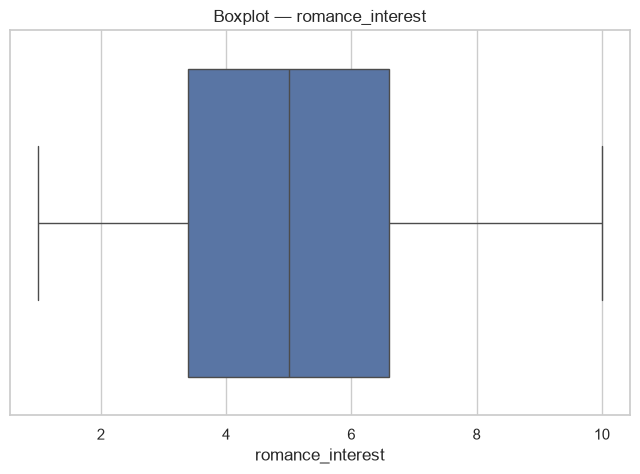

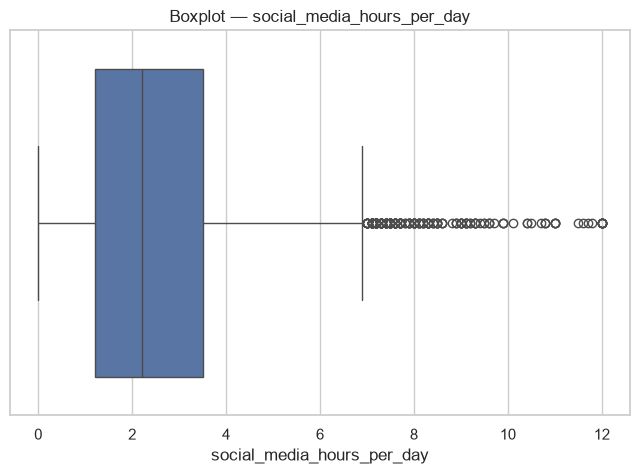

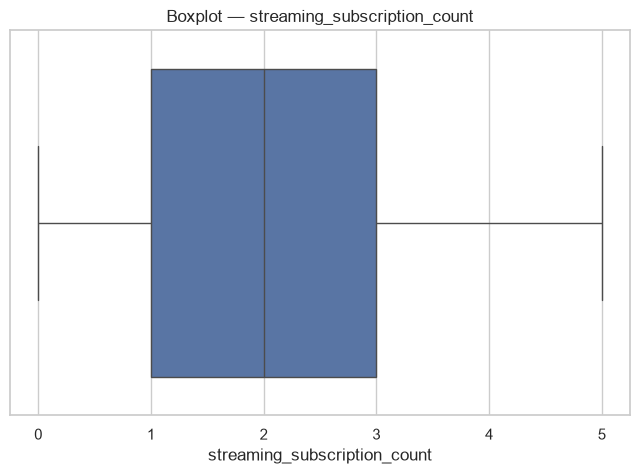

In [15]:
plot_numerical_boxplots(df) # Gráficos de caixa das variáveis numéricas para identificar possíveis outliers

In [17]:
resultado = detectar_outliers_iqr(df, "mood_score")

print(f"Q1 = {resultado['Q1']}")
print(f"Q3 = {resultado['Q3']}")
print(f"IQR = {resultado['IQR']}")
print(f"Limite inferior: {resultado['limite_inferior']:.2f}")
print(f"Limite superior: {resultado['limite_superior']:.2f}")
print(f"Quantidade de outliers: {resultado['quantidade_outliers']}")

Q1 = 4.9
Q3 = 7.5
IQR = 2.5999999999999996
Limite inferior: 1.00
Limite superior: 11.40
Quantidade de outliers: 32


In [18]:
resultado = detectar_outliers_zscore(df,"mood_score")

print(
    f"Quantidade de outliers: "
    f"{resultado['quantidade_outliers']}"
)

resultado["outliers"].head()

Quantidade de outliers: 0


,person_id,age_group,gender,personality_type,mood_score,stress_level,hobbies,favorite_game_genre,favorite_music_genre,fear_tolerance,risk_tolerance,humor_preference,openness_score,romance_interest,social_media_hours_per_day,preferred_language,relationship_status,favorite_season,sleep_pattern,education_level,occupation,income_bracket,preferred_streaming_platform,preferred_watch_time,viewing_companion,snack_preference,preferred_device,preferred_movie_length,favorite_movie_era,exercise_frequency,pet_ownership,streaming_subscription_count,travel_frequency,book_reading_frequency,recommended_movie_genre,zscore


In [12]:
df_limpo['stress_level'].value_counts()

stress_level
1.0    223
4.5    136
5.5    123
4.9    122
5.1    122
      ... 
9.4     12
9.9      9
9.8      8
9.7      8
9.6      7
Name: count, Length: 91, dtype: int64

In [16]:
df_limpo['social_media_hours_per_day'].value_counts()

social_media_hours_per_day
1.0     185
1.6     180
1.5     177
1.2     169
1.3     167
       ... 
11.6      1
11.5      1
9.4       1
11.7      1
10.5      1
Name: count, Length: 109, dtype: int64

In [10]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   person_id                     6000 non-null   int64  
 1   age_group                     6000 non-null   str    
 2   gender                        6000 non-null   str    
 3   personality_type              6000 non-null   str    
 4   mood_score                    6000 non-null   float64
 5   stress_level                  6000 non-null   float64
 6   hobbies                       6000 non-null   str    
 7   favorite_game_genre           6000 non-null   str    
 8   favorite_music_genre          6000 non-null   str    
 9   fear_tolerance                6000 non-null   float64
 10  risk_tolerance                6000 non-null   float64
 11  humor_preference              6000 non-null   float64
 12  openness_score                6000 non-null   float64
 13  romance_intere

In [19]:
resultado = detectar_outliers_iqr(df, "social_media_hours_per_day")

print(f"Q1 = {resultado['Q1']}")
print(f"Q3 = {resultado['Q3']}")
print(f"IQR = {resultado['IQR']}")
print(f"Limite inferior: {resultado['limite_inferior']:.2f}")
print(f"Limite superior: {resultado['limite_superior']:.2f}")
print(f"Quantidade de outliers: {resultado['quantidade_outliers']}")

Q1 = 1.2
Q3 = 3.5
IQR = 2.3
Limite inferior: -2.25
Limite superior: 6.95
Quantidade de outliers: 189


In [20]:
resultado = detectar_outliers_zscore(df,"social_media_hours_per_day")

print(
    f"Quantidade de outliers: "
    f"{resultado['quantidade_outliers']}"
)

resultado["outliers"].head()

Quantidade de outliers: 83


,person_id,age_group,gender,personality_type,mood_score,stress_level,hobbies,favorite_game_genre,favorite_music_genre,fear_tolerance,risk_tolerance,humor_preference,openness_score,romance_interest,social_media_hours_per_day,preferred_language,relationship_status,favorite_season,sleep_pattern,education_level,occupation,income_bracket,preferred_streaming_platform,preferred_watch_time,viewing_companion,snack_preference,preferred_device,preferred_movie_length,favorite_movie_era,exercise_frequency,pet_ownership,streaming_subscription_count,travel_frequency,book_reading_frequency,recommended_movie_genre,zscore
250,251,Senior (60+),Female,Extrovert,9.9,3.3,Gardening,Puzzle,Rock,7.0,6.6,5.0,6.1,2.7,8.3,English,Divorced,Autumn,Night Owl,Bachelor's Degree,Healthcare,Middle ($50k-90k),Amazon Prime,Afternoon,Alone,No Snacks,Laptop,Long (120-160 min),Classic (pre-1980),1-2 times/week,No Pets,0,Never,A few books a year,Action,3.111592
287,288,Senior (60+),Male,Extrovert,9.8,3.4,"Cooking, Fitness",Racing,Pop,1.2,9.2,8.1,8.4,3.6,8.3,French,In a relationship,Spring,Night Owl,Bachelor's Degree,Software/IT,Upper-Middle ($90k-150k),Netflix,Evening,Alone,No Snacks,Cinema Screen,Long (120-160 min),80s/90s,1-2 times/week,Has Dog,4,Frequently (weekly/biweekly),Never,Action,3.111592
508,509,Young Adult (18-25),Female,Extrovert,8.3,5.5,"Gaming, Reading",Strategy,Pop,3.2,1.6,2.7,6.6,4.0,8.4,English,Divorced,Winter,Night Owl,Master's Degree,Homemaker,Upper-Middle ($90k-150k),Netflix,Late Night,With Partner,No Snacks,Cinema Screen,Standard (90-120 min),Classic (pre-1980),1-2 times/week,Has Dog,4,2-3 times/year,A few books a year,Drama,3.166062
572,573,Teen (13-17),Non-binary,Introvert,8.5,5.4,"Writing, Music, Gardening",Action,Pop,7.5,7.3,5.8,2.8,4.9,8.1,Korean,Divorced,Winter,Night Owl,High School,Education,Upper-Middle ($90k-150k),YouTube,Evening,Alone,No Snacks,Laptop,Epic (160+ min),2000s,1-2 times/week,Has Cat,2,Never,1-2 books/month,Action,3.002654
590,591,Teen (13-17),Female,Extrovert,6.1,3.9,"Fitness, Writing, Reading",Racing,Rock,7.6,1.9,6.6,8.9,7.9,8.9,Hindi,Single,Summer,Irregular,Bachelor's Degree,Software/IT,High (>$150k),Hulu,Late Night,With Partner,Healthy Snacks,Smart TV,Standard (90-120 min),80s/90s,Rarely,Has Cat,3,Frequently (weekly/biweekly),Weekly reader,Animation,3.438408


In [18]:
variaveis_interesse = [
    "mood_score", "stress_level", "fear_tolerance", "risk_tolerance", 
    "humor_preference", "openness_score", "romance_interest", "social_media_hours_per_day", "streaming_subscription_count"
]

matriz_corr = get_correlation_matrix(df, variaveis_interesse)

matriz_corr.round(2)

,mood_score,stress_level,fear_tolerance,risk_tolerance,humor_preference,openness_score,romance_interest,social_media_hours_per_day,streaming_subscription_count
mood_score,1.00,0.01,0.01,0.02,0.02,-0.02,-0.01,0.02,0.01
stress_level,0.01,1.00,-0.01,-0.02,0.01,-0.01,0.01,0.00,-0.02
fear_tolerance,0.01,-0.01,1.00,0.01,0.00,-0.00,0.02,-0.01,-0.03
risk_tolerance,0.02,-0.02,0.01,1.00,0.01,0.02,-0.02,-0.01,-0.01
humor_preference,0.02,0.01,0.00,0.01,1.00,0.00,0.03,0.00,-0.00
openness_score,-0.02,-0.01,-0.00,0.02,0.00,1.00,-0.00,0.01,0.00
romance_interest,-0.01,0.01,0.02,-0.02,0.03,-0.00,1.00,-0.02,0.00
social_media_hours_per_day,0.02,0.00,-0.01,-0.01,0.00,0.01,-0.02,1.00,-0.02
streaming_subscription_count,0.01,-0.02,-0.03,-0.01,-0.00,0.00,0.00,-0.02,1.00


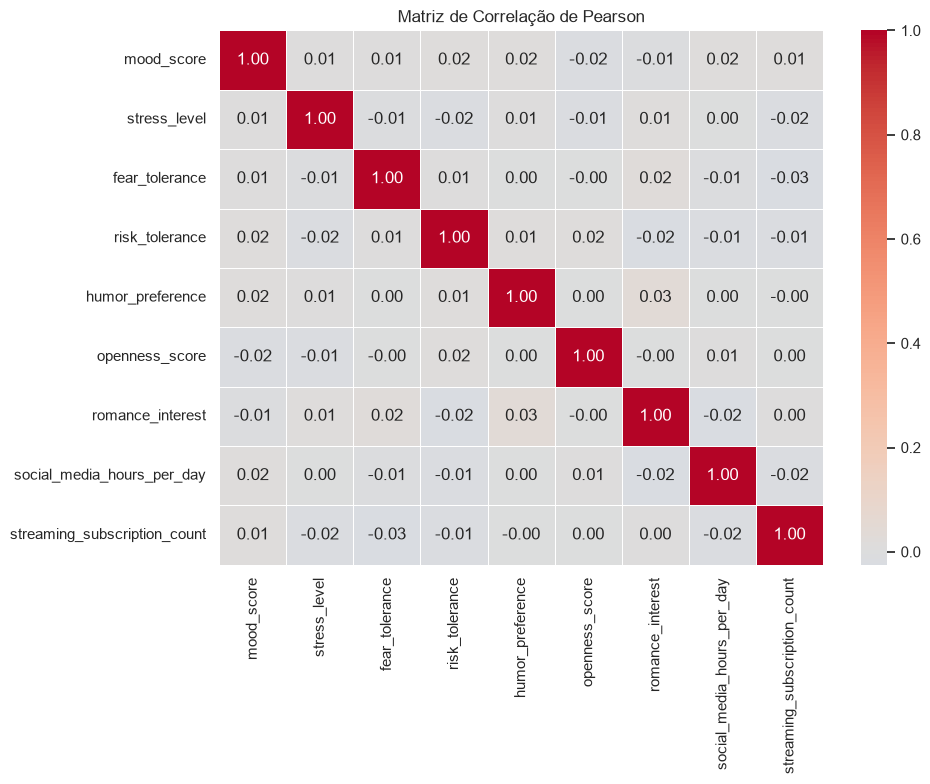

In [6]:
plot_correlation_matrix(matriz_corr)

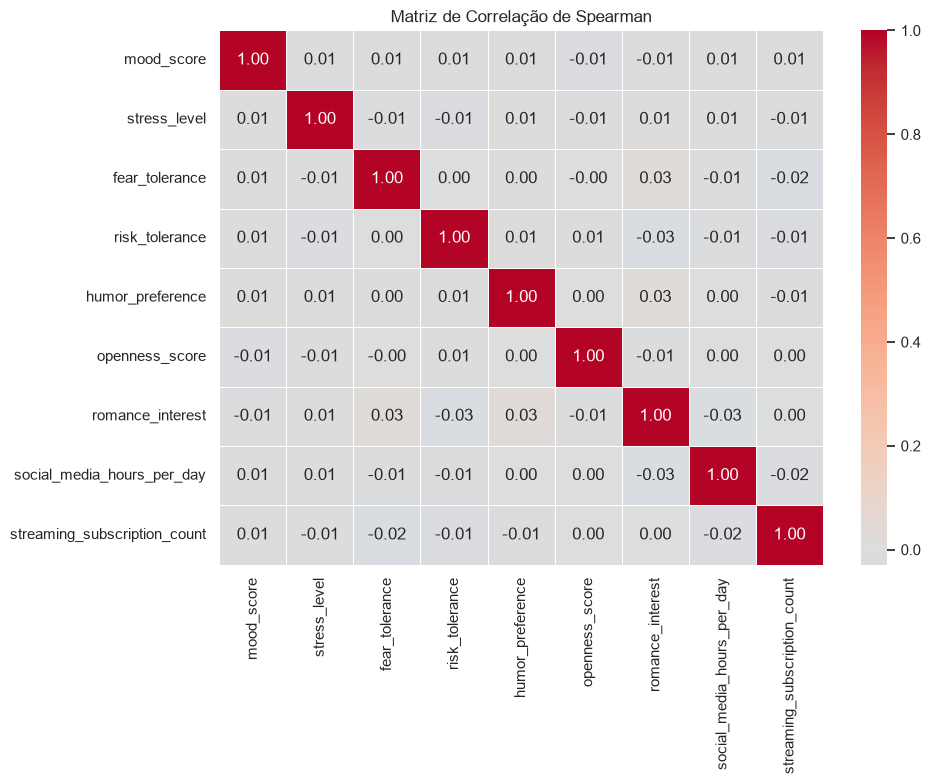

In [23]:
matriz_corr_spearman = df_limpo[variaveis_interesse].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Matriz de Correlação de Spearman")
plt.tight_layout()
plt.show()

In [3]:
num_cols = ["mood_score", "stress_level", "social_media_hours_per_day"]

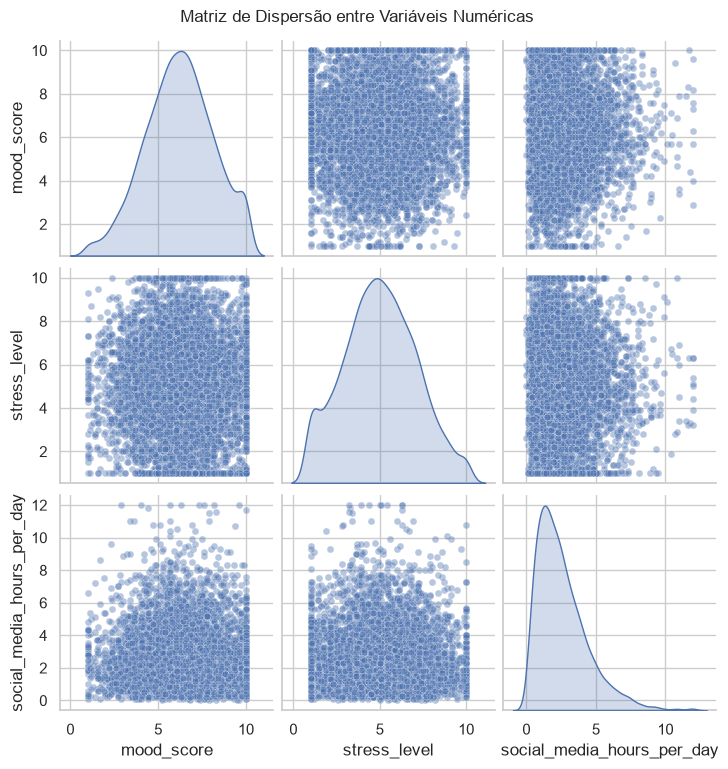

In [4]:
plot_pairplot(df, num_cols)

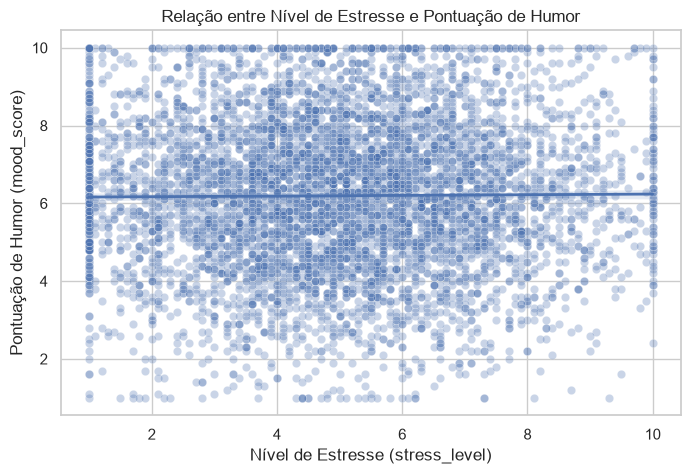

In [5]:
plot_stress_vs_mood(df)

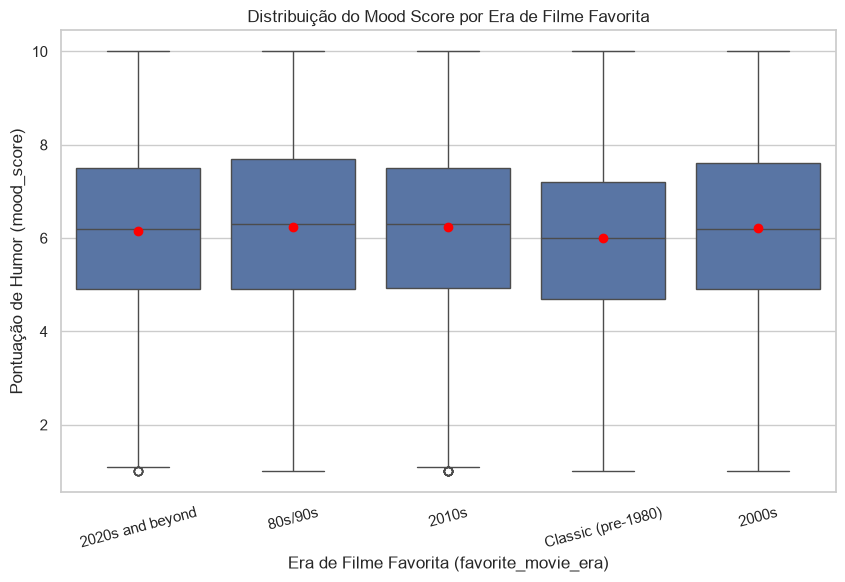

In [6]:
plot_mood_by_movie_era(df)

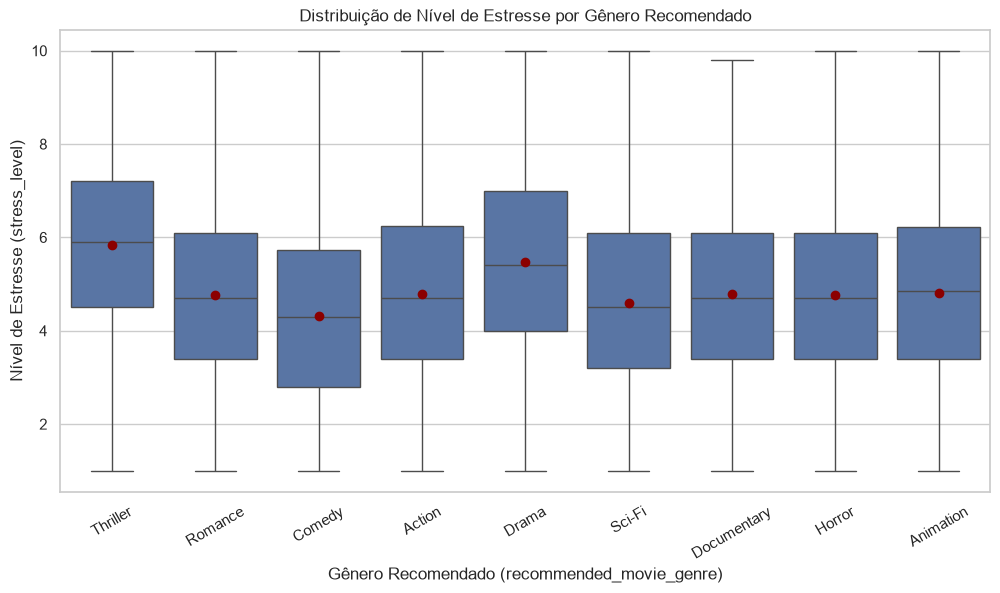

In [7]:
plot_stress_by_recommended_genre(df)

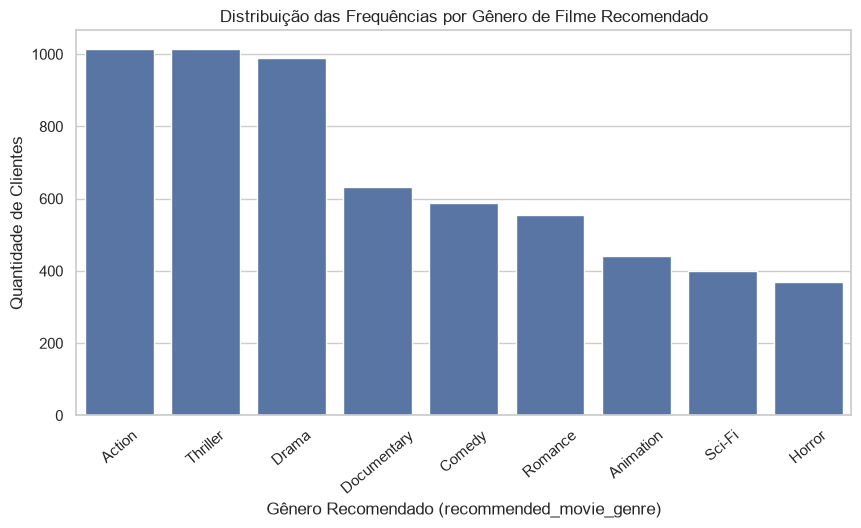

In [8]:
plot_recommended_genre_frequency(df)

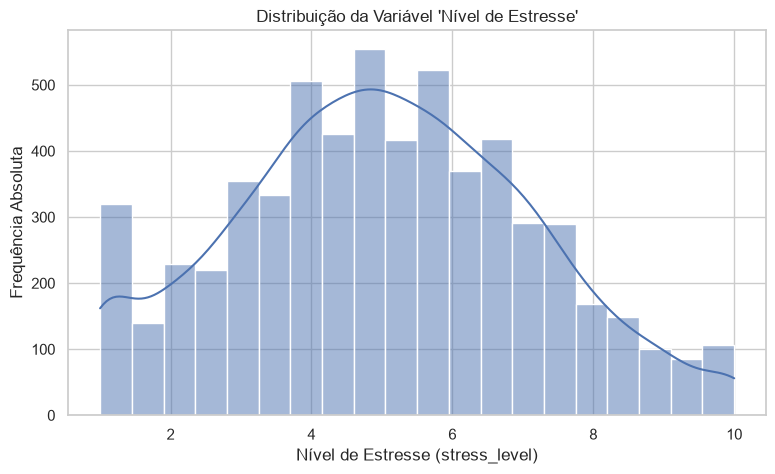

In [9]:
plot_stress_distribution(df)